# Factor Bar Chart and Timeseries Figures

In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

In [2]:
# force the math text to look normal
mpl.rcParams['mathtext.default'] = 'regular'

def major_ticks(x, pos=None):
    """Set the major ticks according
    to this custom style
    """
    x = mdates.num2date(x)
    if pos == 0:
        fmt = "%-d\n%b %Y\n%I %p"
    else:
        fmt = "%-d"
    return x.strftime(fmt)

# set the default seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
#load in the comp data
comp = pd.read_csv('4_factor_resid.csv')
comp.rename(columns={'Unnamed: 0':'species'},inplace=True)
comp

,species,Factor 1,Factor 2,Factor 3,Factor 4,Residual
0,co,0.584572,0.253683,0.135708,0.007308,0.018728
1,no,0.692095,0.218151,0.073244,0.002320,0.014190
2,no2,0.109242,0.887996,0.001750,0.001290,-0.000279
3,o3,0.891506,0.000574,0.108307,0.000000,-0.000387
4,bin0,0.172676,0.023722,0.804322,0.000000,-0.000720
5,bin1,0.000000,0.000000,0.698886,0.361037,-0.059923
6,bin2,0.031610,0.047689,0.316620,0.601474,0.002607
7,bin3,0.233611,0.028868,0.032523,0.704134,0.000864
8,bin4,0.427359,0.000000,0.000000,0.582216,-0.009575
9,bin5,0.522128,0.000000,0.000000,0.489512,-0.011640


In [4]:
comp2 = pd.melt(comp,id_vars='species', value_vars=['Factor 1','Factor 2','Factor 3','Factor 4','Residual'])
comp2

,species,variable,value
0,co,Factor 1,0.584572
1,no,Factor 1,0.692095
2,no2,Factor 1,0.109242
3,o3,Factor 1,0.891506
4,bin0,Factor 1,0.172676
5,bin1,Factor 1,0.000000
6,bin2,Factor 1,0.031610
7,bin3,Factor 1,0.233611
8,bin4,Factor 1,0.427359
9,bin5,Factor 1,0.522128


In [5]:
#load in the timeseries data
ts = pd.read_csv('MOD-000689_timeseries_hourly_scaled.csv').reset_index()
results = pd.read_csv('4_factor_results.csv')

ts = pd.concat([ts,results['Factor 1'],results['Factor 2'], results['Factor 3'], results['Factor 4']], axis = 1)
cols_reordered = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','co','o3','no','no2','Factor 1','Factor 2','Factor 3','Factor 4']
ts = ts[cols_reordered]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Factor 4
0,2025-03-31 20:00:00,0.288392,0.090945,0.089623,0.126074,0.188623,0.128866,0.103370,0.502305,0.007002,0.671112,0.042232,0.109377,0.053291,0.069352
1,2025-03-31 21:00:00,0.383505,0.149325,0.113994,0.137536,0.200599,0.141753,0.111645,0.531268,0.008801,0.777566,0.040019,0.127922,0.075923,0.081263
2,2025-03-31 22:00:00,0.329353,0.178316,0.115566,0.114613,0.143713,0.092784,0.104935,0.622887,0.009375,0.599905,0.051615,0.095369,0.066956,0.071541
3,2025-03-31 23:00:00,0.254374,0.194996,0.117138,0.094556,0.098802,0.051546,0.091747,0.715924,0.009298,0.350322,0.064680,0.050094,0.052471,0.064117
4,2025-04-01 00:00:00,0.238267,0.133836,0.077044,0.063037,0.068862,0.038660,0.085182,0.754463,0.008801,0.314599,0.070070,0.043248,0.047123,0.038850


In [6]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local']) #convert timestamp column to pandas timestamp format
ts = ts.set_index('timestamp_local',append=False) #setindex as local time
ts

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Factor 4
timestamp_local,,,,,,,,,,,,,,
2025-03-31 20:00:00,0.288392,0.090945,0.089623,0.126074,0.188623,0.128866,0.103370,0.502305,0.007002,0.671112,0.042232,0.109377,0.053291,0.069352
2025-03-31 21:00:00,0.383505,0.149325,0.113994,0.137536,0.200599,0.141753,0.111645,0.531268,0.008801,0.777566,0.040019,0.127922,0.075923,0.081263
2025-03-31 22:00:00,0.329353,0.178316,0.115566,0.114613,0.143713,0.092784,0.104935,0.622887,0.009375,0.599905,0.051615,0.095369,0.066956,0.071541
2025-03-31 23:00:00,0.254374,0.194996,0.117138,0.094556,0.098802,0.051546,0.091747,0.715924,0.009298,0.350322,0.064680,0.050094,0.052471,0.064117
2025-04-01 00:00:00,0.238267,0.133836,0.077044,0.063037,0.068862,0.038660,0.085182,0.754463,0.008801,0.314599,0.070070,0.043248,0.047123,0.038850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 14:00:00,0.102194,0.023431,0.014151,0.008596,0.008982,0.002577,0.086822,0.546873,0.007729,0.670160,0.054933,0.107912,0.016119,0.000089
2025-12-31 15:00:00,0.098167,0.023828,0.014151,0.008596,0.008982,0.002577,0.089836,0.539780,0.007423,0.672303,0.054384,0.108409,0.015349,0.000410
2025-12-31 16:00:00,0.108998,0.027403,0.016509,0.008596,0.008982,0.005155,0.090700,0.517082,0.009298,0.684449,0.051326,0.110986,0.018123,0.001059


In [7]:
#taking daily average of ts. round to floor of the day
ts = ts.reset_index()

ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  factor1 = ('Factor 1','mean'),
                                                  factor2 = ('Factor 2','mean'),
                                                  factor3 = ('Factor 3','mean'),
                                                  factor4 = ('Factor 4','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,factor1,factor2,factor3,factor4
timestamp_local,,,,,,,,,,,,,,
2025-03-31,0.313906,0.153396,0.109080,0.118195,0.157934,0.103737,0.102924,0.593096,0.008619,0.599726,0.049637,0.095690,0.062160,0.071568
2025-04-01,0.083073,0.037497,0.024076,0.021012,0.022829,0.012564,0.081329,0.678937,0.008090,0.247162,0.070365,0.032089,0.011369,0.010004
2025-04-02,0.062998,0.025913,0.027319,0.039995,0.058508,0.038982,0.089005,0.724037,0.007648,0.411050,0.076967,0.059463,0.003982,0.019872
2025-04-03,0.293969,0.103753,0.074817,0.099928,0.155190,0.110717,0.104358,0.535510,0.007796,0.533798,0.044999,0.085227,0.056641,0.057752
2025-04-04,0.089512,0.041220,0.044811,0.068887,0.133982,0.120168,0.091380,0.600869,0.008157,0.313716,0.062735,0.044642,0.010264,0.047018


## Setting Up Barchart and 6-month Figures

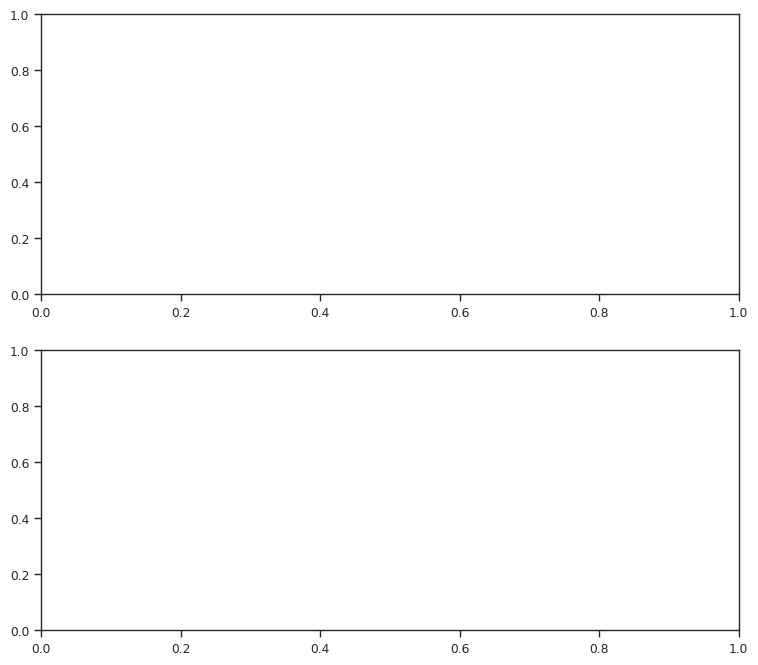

In [8]:
# set up the figure
fig = plt.figure(figsize=(9,8))

ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

In [9]:
cols = ['bin0', 'bin1', 'bin2','bin3','bin4','bin5','co', 'o3','no', 'no2']

pal = sns.color_palette()

colors = [pal[3], pal[2], pal[4], pal[5]]
colors += sns.color_palette("Blues", 6)
colors.reverse()

In [10]:
ax1 = sns.barplot(x='variable',y='value',
        data=comp2,
        ax=ax1, hue='species',hue_order=cols,
        palette=colors, saturation=1, edgecolor='black', linewidth=0.25,
        errwidth=.75)

/tmp/ipykernel_19728/2976516543.py:1: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.75}` instead.

  ax1 = sns.barplot(x='variable',y='value',


In [11]:
ax1.set_ylim(-0.2, 1)
ax1.set_xlabel("")
ax1.set_ylabel("Percent of Species Signal\nDescribed by Factor", fontsize=14)
ax1.set(yticks=np.linspace(-0.2, 1, 13), yticklabels=["","","0","","","","","50","","","","","100"])
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.axhline(y=0, color='black', linestyle='-', lw =0.5)

In [12]:
handles, _ = ax1.get_legend_handles_labels()
labels = ["Bin 0", "Bin 1", "Bin 2", "Bin 3","Bin 4","Bin 5","CO","$O_3$","$NO$", "$NO_2$"]
ax1.legend(handles, labels)

In [13]:
ax2.plot(ts_day.index, ts_day["factor1"], label="Factor 1 ", lw=1, color=sns.xkcd_rgb['slate blue'])
ax2.plot(ts_day.index, ts_day["factor2"], label="Factor 2", lw=1, color=sns.xkcd_rgb['dull green'])
ax2.plot(ts_day.index, ts_day["factor3"], label="Factor 3", lw=1, color=sns.xkcd_rgb['dark lavender'])
ax2.plot(ts_day.index, ts_day["factor4"], label="Factor 4", lw=1, color=sns.xkcd_rgb['faded red'])

ax2.set_ylabel("Factor Intensity (a.u.)", fontsize=14)

#last 6 months
ax2.set_xlim(ts_day.index[max(0, len(ts_day) - 180)], ts_day.index[-1])
#ax2.set_xlim(ts_day.index[0], ts_day.index[-1])

ax2.legend(loc='upper right',fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=14)

In [14]:
ax1.set_title('(a)',fontsize=14)
ax2.set_title('(b)',fontsize=14)

Text(0.5, 1.0, '(b)')

In [15]:
plt.gcf().text(0.09, 0.9, "(a)", fontsize=12)
plt.gcf().text(0.5, 0.9, "(b)", fontsize=12)
plt.gcf().text(0.09,0.9,'MOD-00689',fontsize=12)

plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [17]:
fig.savefig('time_barchart_MOD-000689_4_factor.png')

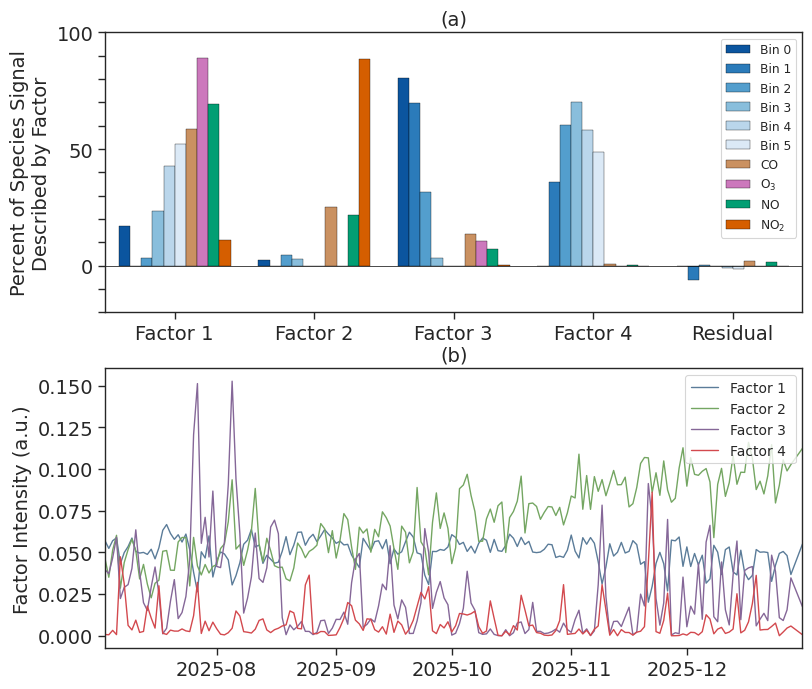

In [16]:
fig

## Setting Up Diurnal Figure

In [18]:
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Factor 4
0,2025-03-31 20:00:00,0.288392,0.090945,0.089623,0.126074,0.188623,0.128866,0.103370,0.502305,0.007002,0.671112,0.042232,0.109377,0.053291,0.069352
1,2025-03-31 21:00:00,0.383505,0.149325,0.113994,0.137536,0.200599,0.141753,0.111645,0.531268,0.008801,0.777566,0.040019,0.127922,0.075923,0.081263
2,2025-03-31 22:00:00,0.329353,0.178316,0.115566,0.114613,0.143713,0.092784,0.104935,0.622887,0.009375,0.599905,0.051615,0.095369,0.066956,0.071541
3,2025-03-31 23:00:00,0.254374,0.194996,0.117138,0.094556,0.098802,0.051546,0.091747,0.715924,0.009298,0.350322,0.064680,0.050094,0.052471,0.064117
4,2025-04-01 00:00:00,0.238267,0.133836,0.077044,0.063037,0.068862,0.038660,0.085182,0.754463,0.008801,0.314599,0.070070,0.043248,0.047123,0.038850


In [19]:
#prepping data
ts = ts.set_index('timestamp_local')
ts['Hour'] = ts.index.hour
ts.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Factor 4,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-03-31 20:00:00,0.288392,0.090945,0.089623,0.126074,0.188623,0.128866,0.103370,0.502305,0.007002,0.671112,0.042232,0.109377,0.053291,0.069352,20
2025-03-31 21:00:00,0.383505,0.149325,0.113994,0.137536,0.200599,0.141753,0.111645,0.531268,0.008801,0.777566,0.040019,0.127922,0.075923,0.081263,21
2025-03-31 22:00:00,0.329353,0.178316,0.115566,0.114613,0.143713,0.092784,0.104935,0.622887,0.009375,0.599905,0.051615,0.095369,0.066956,0.071541,22
2025-03-31 23:00:00,0.254374,0.194996,0.117138,0.094556,0.098802,0.051546,0.091747,0.715924,0.009298,0.350322,0.064680,0.050094,0.052471,0.064117,23
2025-04-01 00:00:00,0.238267,0.133836,0.077044,0.063037,0.068862,0.038660,0.085182,0.754463,0.008801,0.314599,0.070070,0.043248,0.047123,0.038850,0


In [20]:
#groupping by hour and calculate the mean
diurnal_data = ts.groupby('Hour')[['Factor 1','Factor 2','Factor 3','Factor 4']].mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,Factor 1,Factor 2,Factor 3,Factor 4
Hour,,,,
00:00,0.051098,0.070811,0.028998,0.014285
01:00,0.049901,0.068941,0.029962,0.013255
02:00,0.048809,0.069674,0.030445,0.012742
03:00,0.047629,0.069026,0.031065,0.012963
04:00,0.046448,0.069694,0.032057,0.013540
05:00,0.044537,0.072127,0.032667,0.014755
06:00,0.042975,0.076984,0.033193,0.015074
07:00,0.043624,0.076482,0.032018,0.015333
08:00,0.045020,0.065736,0.030855,0.012808


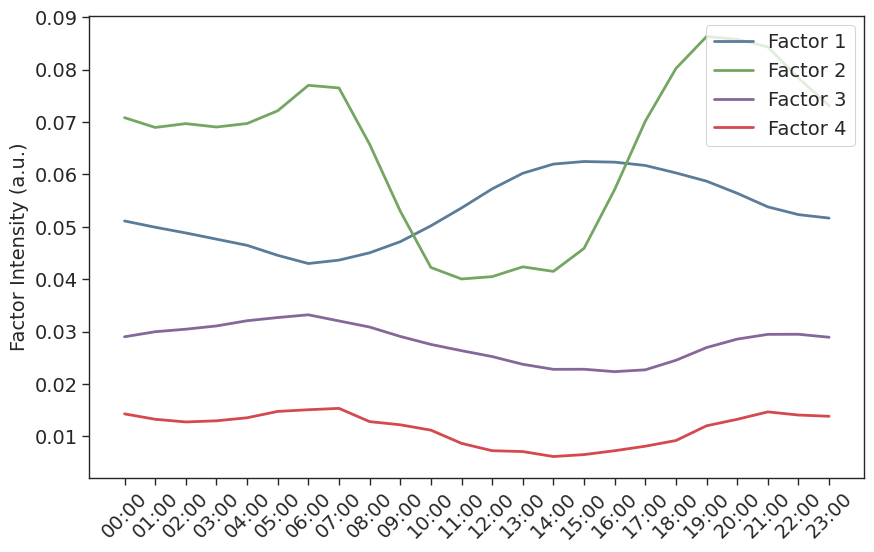

In [21]:
# set up the figure
plt.figure(figsize=(10, 6))

plt.plot(diurnal_data.index, diurnal_data['Factor 1'], label='Factor 1', lw = 2, color=sns.xkcd_rgb['slate blue'])
plt.plot(diurnal_data.index, diurnal_data['Factor 2'], label='Factor 2', lw = 2, color=sns.xkcd_rgb['dull green'])
plt.plot(diurnal_data.index, diurnal_data['Factor 3'], label='Factor 3', lw = 2, color=sns.xkcd_rgb['dark lavender'])
plt.plot(diurnal_data.index, diurnal_data['Factor 4'], label='Factor 4', lw = 2, color=sns.xkcd_rgb['faded red'])

plt.ylabel('Factor Intensity (a.u.)', fontsize = 14)
plt.legend(loc='upper right',fontsize=14)
plt.xticks(range(0, 24))
plt.xticks(rotation=45)

plt.tick_params(labelsize=14)

plt.savefig('diurnal_MOD-000689_4_factor.png')
plt.show()